In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("data/ObesityDataSet_raw_and_data_sinthetic.csv")
X = df.drop(columns=["NObeyesdad"])
y = df["NObeyesdad"]

print(f"\n{df['CAEC'].value_counts().to_string()}")
print(f"\n{df['CALC'].value_counts().to_string()}")
print(f"\n{df['MTRANS'].value_counts().to_string()}")


CAEC
Sometimes     1765
Frequently     242
Always          53
no              51

CALC
Sometimes     1401
no             639
Frequently      70
Always           1

MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7


In [3]:
X['Gender'] = X['Gender'].map({"Female": 0, "Male": 1})
X['family_history_with_overweight'] = X['family_history_with_overweight'].map({"no": 0, "yes": 1})
X['FAVC'] = X['FAVC'].map({"no": 0, "yes": 1})
X['CAEC'] = X['CAEC'].map({"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3})
X['SMOKE'] = X['SMOKE'].map({"no": 0, "yes": 1})
X['SCC'] = X['SCC'].map({"no": 0, "yes": 1})
X['CALC'] = X['CALC'].map({"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3})
X['MTRANS'] = X['MTRANS'].map({"Automobile": 0, "Motorbike": 1, "Bike": 2, "Public_Transportation": 3, "Walking": 4})

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape: ", X_test.shape)

Training shape: (1688, 16)
Testing shape:  (423, 16)


In [ ]:
#knn pipeline
from sklearn.model_selection import GridSearchCV


pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif)),
    ("classifier", KNeighborsClassifier())
])

param_grid_knn = {
    "selector__k": [4, 8, 12, 16],
    "classifier__n_neighbors": list(range(1, 21)),
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Best Parameters:", grid_knn.best_params_)
print("Best CV Accuracy:", f"{grid_knn.best_score_:.4f}")

Best Parameters: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 4, 'classifier__weights': 'distance', 'selector__k': 16}
Best CV Accuracy: 0.8803


In [34]:
# evaluate on test set
best_model_knn = grid_knn.best_estimator_


print(f"KNN Training Accuracy: {best_model_knn.score(X_train, y_train):.4f}")
print(f"KNN Test Accuracy:     {best_model_knn.score(X_test, y_test):.4f}")

KNN Training Accuracy: 1.0000
KNN Test Accuracy:     0.8723


In [32]:
# classification report
y_pred_knn = best_model_knn.predict(X_test)
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

                     precision    recall  f1-score   support

Insufficient_Weight       0.83      0.95      0.88        56
      Normal_Weight       0.83      0.63      0.72        62
     Obesity_Type_I       0.89      0.91      0.90        78
    Obesity_Type_II       0.97      0.98      0.97        58
   Obesity_Type_III       0.98      1.00      0.99        63
 Overweight_Level_I       0.83      0.80      0.82        56
Overweight_Level_II       0.75      0.82      0.78        50

           accuracy                           0.87       423
          macro avg       0.87      0.87      0.87       423
       weighted avg       0.87      0.87      0.87       423



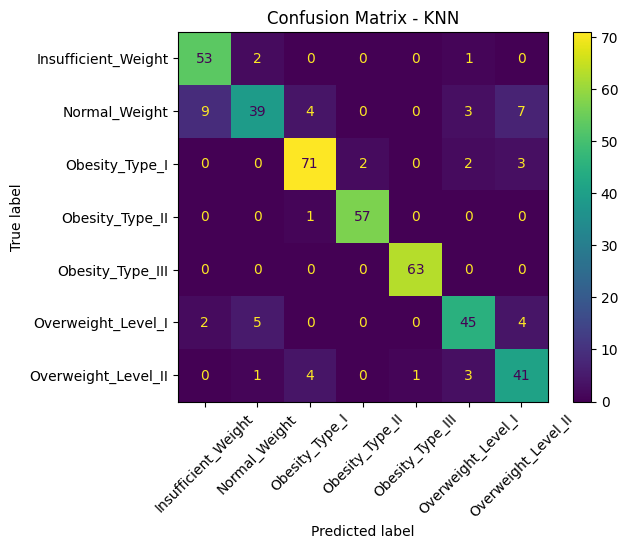

In [39]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - KNN")
plt.savefig("knn_confusion_matrix.png", bbox_inches="tight")
plt.show()



In [ ]:
# gradient boosting pipeline
pipeline_gb = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif)),
    ("classifier", GradientBoostingClassifier())
])

param_grid_gb = {
    "selector__k": [4, 8, 12, 16],
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.01, 0.1],
    "classifier__max_depth": [3, 5]
}

grid_gb = GridSearchCV(
    pipeline_gb,    
    param_grid_gb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_gb.fit(X_train, y_train)

print("Best Parameters (GB):", grid_gb.best_params_)
print("Best CV Accuracy (GB):", f"{grid_gb.best_score_:.4f}")



Best Parameters (GB): {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'selector__k': 16}
Best CV Accuracy (GB): 0.9650


In [24]:
best_model_gb = grid_gb.best_estimator_

print(f"Gradient Boosting Training Accuracy: {best_model_gb.score(X_train, y_train):.4f}")
print(f"Gradient Boosting Test Accuracy:     {best_model_gb.score(X_test, y_test):.4f}")

Gradient Boosting Training Accuracy: 1.0000
Gradient Boosting Test Accuracy:     0.9598


In [25]:
# classification report
best_model_gb = grid_gb.best_estimator_
y_pred_gb = best_model_gb.predict(X_test)
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))

                     precision    recall  f1-score   support

Insufficient_Weight       0.93      1.00      0.97        56
      Normal_Weight       0.96      0.87      0.92        62
     Obesity_Type_I       0.99      0.94      0.96        78
    Obesity_Type_II       0.95      0.98      0.97        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.90      0.96      0.93        56
Overweight_Level_II       0.98      0.98      0.98        50

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



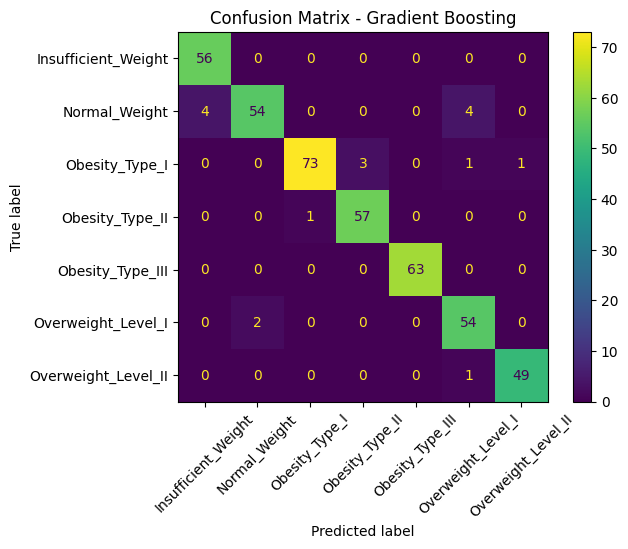

In [38]:
# confusion matrix
y_pred_gb = best_model_gb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)   
plt.title("Confusion Matrix - Gradient Boosting")
plt.savefig("gradient_boosting_confusion_matrix.png", bbox_inches="tight")
plt.show()